# Bayesian History Matching & Production Forecasting

This notebook builds a predictive model mapping reservoir parameters to production responses using Bayesian methods (GPR with Matern kernels, Bayesian Ridge). It performs history matching against observed field production and generates P10/P50/P90 probabilistic forecasts over 20 years.

In [1]:
%pip install seaborn openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize
import mlflow
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

from pathlib import Path
_vol = Path("/Volumes/workspace/default/exxon_mobil_test_cases")
if _vol.exists():
    BASE_PATH = str(_vol)
else:
    _curr = Path.cwd().resolve()
    while not (_curr / "TestCases").exists() and _curr != _curr.parent:
        _curr = _curr.parent
    BASE_PATH = str((_curr / "TestCases").resolve())
print('Libraries loaded successfully')


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/tengkuanas/Projects/mwap-exdw-surrogate-model/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


2026/10/09 10:29:47 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/tengkuanas/Projects/mwap-exdw-surrogate-model/.venv/lib/python3.14/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


Libraries loaded successfully


In [2]:
# Load uncertainty parameters (100 cases x 4 params)
df_params = pd.read_excel(f"{BASE_PATH}/01 Introduction.xlsx", sheet_name='Uncertainty Values', header=0)
df_params.columns = ['Case', 'Fault_Transmissibility', 'Porosity_Mult', 'Perm_Mult', 'Aquifer_PV']
df_params['Case_Num'] = df_params['Case'].str.extract(r'(\d+)').astype(int)

PARAM_COLS = ['Fault_Transmissibility', 'Porosity_Mult', 'Perm_Mult', 'Aquifer_PV']
print(f"Parameters loaded: {df_params.shape[0]} cases x {len(PARAM_COLS)} params")
print(df_params[PARAM_COLS].describe())

# Load observed field production (quarterly rates)
df_obs = pd.read_excel(f"{BASE_PATH}/02 Field Production.xlsx", sheet_name='Field Production', header=0)
df_obs['Date'] = pd.to_datetime(df_obs['Date'])
# Compute cumulative production from rates (quarterly, ~91 days per quarter)
days_per_quarter = 91.25
df_obs['Oil_Cum'] = (df_obs['Oil production rate (STB/d)'] * days_per_quarter).cumsum()
df_obs['Gas_Cum'] = (df_obs['Gas production rate (MSCF/d)'] * days_per_quarter).cumsum()
df_obs['Water_Cum'] = (df_obs['Water production rate (STB/d)'] * days_per_quarter).cumsum()
print(f"\nObserved field production: {df_obs.shape[0]} time steps")
print(f"Date range: {df_obs['Date'].min().date()} to {df_obs['Date'].max().date()}")
print(f"Final cumulative - Oil: {df_obs['Oil_Cum'].iloc[-1]:.0f} STB, Gas: {df_obs['Gas_Cum'].iloc[-1]:.0f} MSCF, Water: {df_obs['Water_Cum'].iloc[-1]:.0f} STB")

# Load cumulative production for all 100 cases (quarterly)
def load_quarterly_cumulative(sheet_name):
    """Load cumulative production data and resample to quarterly."""
    df_raw = pd.read_excel(f"{BASE_PATH}/02 Field Production.xlsx", sheet_name=sheet_name, header=None)
    df = df_raw.iloc[2:].copy()
    df.columns = df_raw.iloc[0].values
    df['X'] = pd.to_datetime(df['X'])
    y_cols = [f'Y{i}' for i in range(1, 101)]
    for c in y_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df_q = df.set_index('X')[y_cols].resample('QS').last()
    return df_q

df_oil_q = load_quarterly_cumulative('Oil production cumulative')
df_gas_q = load_quarterly_cumulative('Gas production cumulative')
df_water_q = load_quarterly_cumulative('Water production cumulative')

print(f"\nQuarterly cumulative shapes - Oil: {df_oil_q.shape}, Gas: {df_gas_q.shape}, Water: {df_water_q.shape}")
print(f"Quarterly time steps: {len(df_oil_q)}")

# Define data splits
TRAIN_CASES = list(range(1, 71))    # Cases 1-70
VAL_CASES = list(range(71, 86))      # Cases 71-85
TEST_CASES = list(range(86, 101))    # Cases 86-100
print(f"\nData split - Train: {len(TRAIN_CASES)} cases, Val: {len(VAL_CASES)} cases, Test: {len(TEST_CASES)} cases")

Parameters loaded: 100 cases x 4 params
       Fault_Transmissibility  Porosity_Mult   Perm_Mult  Aquifer_PV
count              100.000000     100.000000  100.000000  100.000000
mean                 0.099557       1.148462    5.199829  125.165908
std                  0.030082       0.204066    2.726693   42.369751
min                  0.050109       0.801219    0.520527   53.952910
25%                  0.075024       0.977275    2.778165   89.847942
50%                  0.098628       1.144782    5.309227  125.771813
75%                  0.126651       1.348251    7.534620  159.659719
max                  0.149950       1.494027    9.784546  199.835200

Observed field production: 41 time steps
Date range: 1998-01-01 to 2008-01-01
Final cumulative - Oil: 38812562 STB, Gas: 14100140 MSCF, Water: 13525845 STB



Quarterly cumulative shapes - Oil: (41, 100), Gas: (41, 100), Water: (41, 100)
Quarterly time steps: 41

Data split - Train: 70 cases, Val: 15 cases, Test: 15 cases


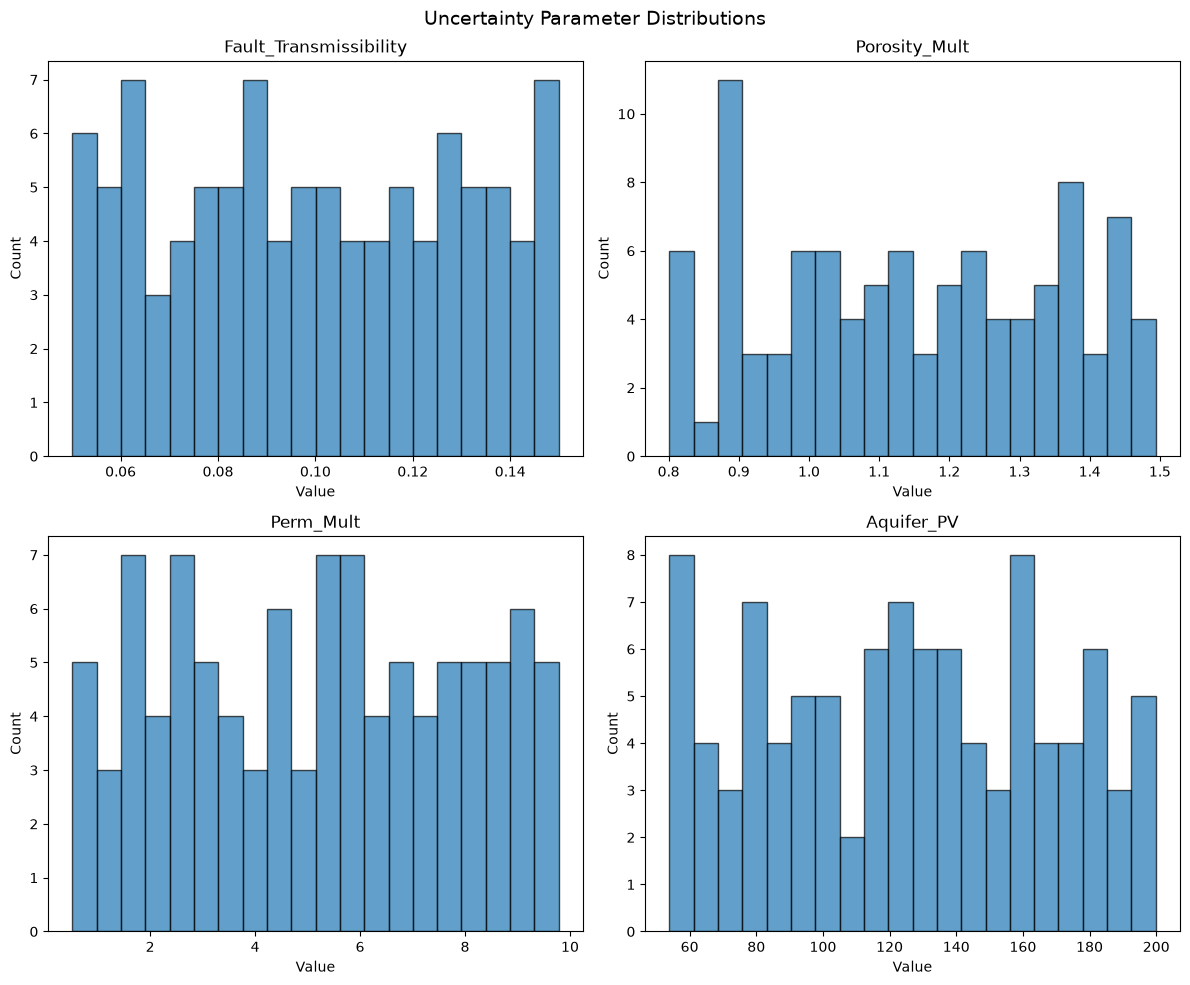

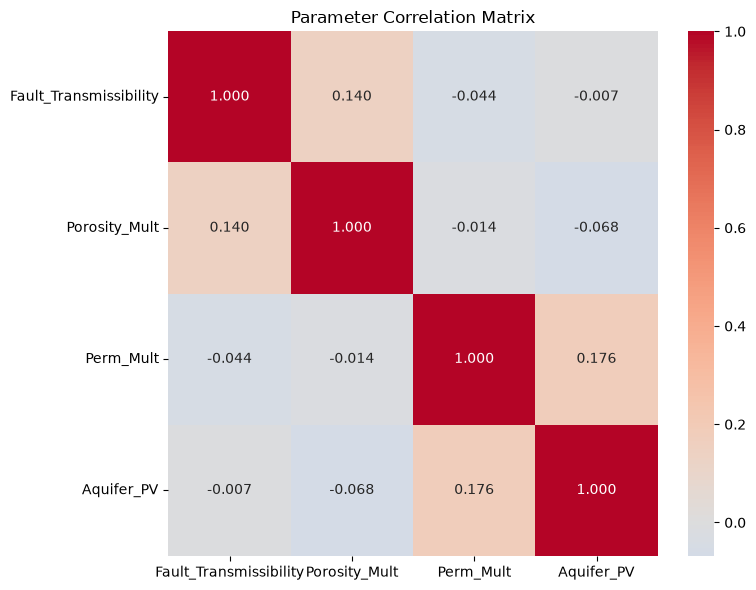

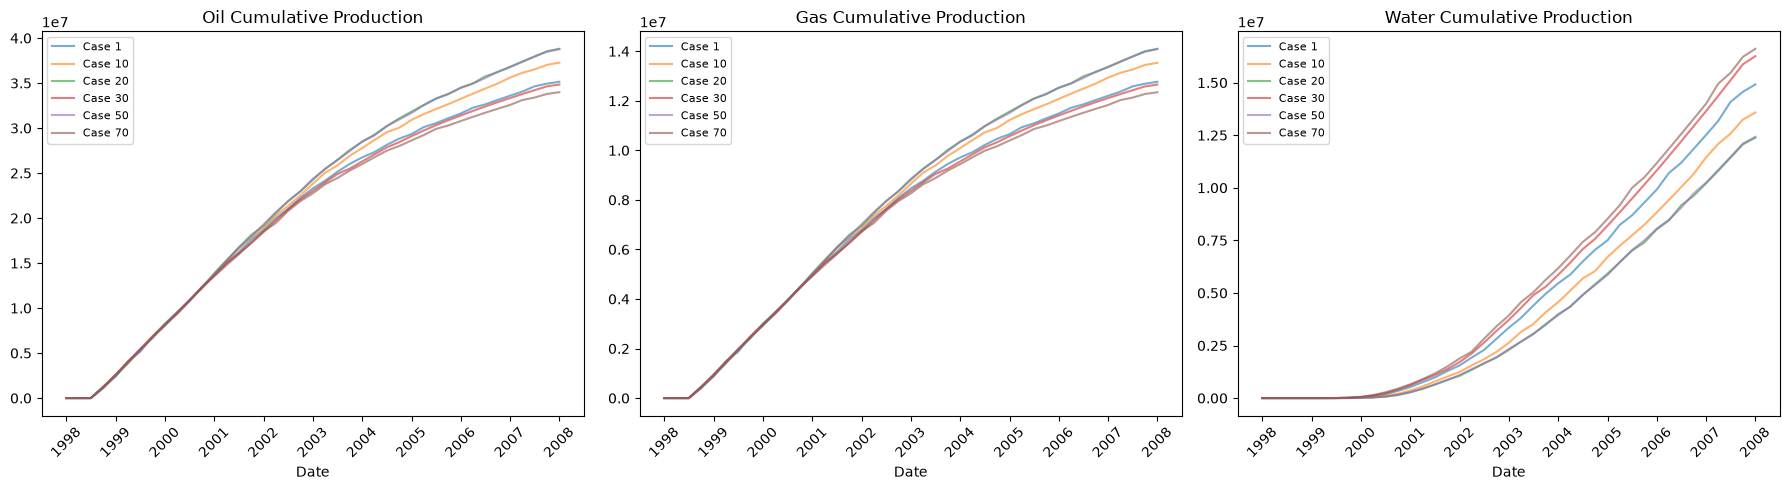


Feature Summary:
| Feature | Type |
|---------|------|
| Fault_Transmissibility | numeric float |
| Porosity_Mult | numeric float |
| Perm_Mult | numeric float |
| Aquifer_PV | numeric float |
| Oil_Cum (per timestep) | numeric float (target) |
| Gas_Cum (per timestep) | numeric float (target) |
| Water_Cum (per timestep) | numeric float (target) |


In [3]:
# --- EDA: Parameter distributions and correlations ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, col in enumerate(PARAM_COLS):
    ax = axes[i//2, i%2]
    ax.hist(df_params[col], bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
plt.suptitle('Uncertainty Parameter Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation matrix of parameters
plt.figure(figsize=(8, 6))
sns.heatmap(df_params[PARAM_COLS].corr(), annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Parameter Correlation Matrix')
plt.tight_layout()
plt.show()

# Show production curves for a sample of training cases
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dates = df_oil_q.index
for case_idx in [1, 10, 20, 30, 50, 70]:
    y_col = f'Y{case_idx}'
    axes[0].plot(dates, df_oil_q[y_col], alpha=0.6, label=f'Case {case_idx}')
    axes[1].plot(dates, df_gas_q[y_col], alpha=0.6, label=f'Case {case_idx}')
    axes[2].plot(dates, df_water_q[y_col], alpha=0.6, label=f'Case {case_idx}')
axes[0].set_title('Oil Cumulative Production')
axes[1].set_title('Gas Cumulative Production')
axes[2].set_title('Water Cumulative Production')
for ax in axes:
    ax.set_xlabel('Date')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Feature table
print("\nFeature Summary:")
print("| Feature | Type |")
print("|---------|------|")
for col in PARAM_COLS:
    print(f"| {col} | numeric float |")
print("| Oil_Cum (per timestep) | numeric float (target) |")
print("| Gas_Cum (per timestep) | numeric float (target) |")
print("| Water_Cum (per timestep) | numeric float (target) |")

In [4]:
# --- Prepare data for surrogate modeling ---
# X: 4 parameters per case
# y: quarterly cumulative production at 41 time steps (oil, gas, water)

def prepare_data(df_cum, case_list):
    """Extract parameter features and cumulative production targets for given cases."""
    X = df_params[df_params['Case_Num'].isin(case_list)][PARAM_COLS].values
    y_cols = [f'Y{c}' for c in case_list]
    y = df_cum[y_cols].T.values  # shape: (n_cases, n_timesteps)
    return X, y

# Prepare oil targets
X_train, y_oil_train = prepare_data(df_oil_q, TRAIN_CASES)
X_val, y_oil_val = prepare_data(df_oil_q, VAL_CASES)
X_test, y_oil_test = prepare_data(df_oil_q, TEST_CASES)

# Prepare gas and water targets
_, y_gas_train = prepare_data(df_gas_q, TRAIN_CASES)
_, y_gas_val = prepare_data(df_gas_q, VAL_CASES)
_, y_gas_test = prepare_data(df_gas_q, TEST_CASES)

_, y_water_train = prepare_data(df_water_q, TRAIN_CASES)
_, y_water_val = prepare_data(df_water_q, VAL_CASES)
_, y_water_test = prepare_data(df_water_q, TEST_CASES)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train.shape}, y_oil_train: {y_oil_train.shape}")
print(f"X_val: {X_val.shape}, y_oil_val: {y_oil_val.shape}")
print(f"X_test: {X_test.shape}, y_oil_test: {y_oil_test.shape}")
print(f"\nScaled X_train mean: {X_train_scaled.mean(axis=0).round(4)}, std: {X_train_scaled.std(axis=0).round(4)}")

# Store quarterly dates for reference
quarterly_dates = df_oil_q.index
n_timesteps = len(quarterly_dates)
print(f"\nNumber of quarterly time steps: {n_timesteps}")

X_train: (70, 4), y_oil_train: (70, 41)
X_val: (15, 4), y_oil_val: (15, 41)
X_test: (15, 4), y_oil_test: (15, 41)

Scaled X_train mean: [-0. -0. -0.  0.], std: [1. 1. 1. 1.]

Number of quarterly time steps: 41


In [5]:
# --- Train Gaussian Process Regression with Matern Kernel ---
# GPR provides posterior mean AND std (uncertainty quantification)
# We train one GPR per time step for each fluid type

mlflow.set_experiment("/Users/wanafiqzafry456@gmail.com/bayesian_history_matching")

fluids = {
    'oil': (y_oil_train, y_oil_val, y_oil_test),
    'gas': (y_gas_train, y_gas_val, y_gas_test),
    'water': (y_water_train, y_water_val, y_water_test)
}

gpr_models = {}
gpr_val_preds = {}
gpr_val_stds = {}
gpr_test_preds = {}
gpr_test_stds = {}

for fluid_name, (y_tr, y_va, y_te) in fluids.items():
    print(f"\nTraining GPR for {fluid_name}...")
    models_t = []
    val_preds_t = []
    val_stds_t = []
    test_preds_t = []
    test_stds_t = []
    
    for t in range(n_timesteps):
        # Matern kernel with nu=2.5 (twice differentiable)
        kernel = ConstantKernel(1.0, (1e-3, 1e3)) * \
                Matern(length_scale=np.ones(4), length_scale_bounds=(1e-2, 1e2), nu=2.5) + \
                WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
        
        gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2, random_state=42)
        gpr.fit(X_train_scaled, y_tr[:, t])
        models_t.append(gpr)
        
        # Validate
        pred_v, std_v = gpr.predict(X_val_scaled, return_std=True)
        val_preds_t.append(pred_v)
        val_stds_t.append(std_v)
        
        # Test
        pred_t, std_t = gpr.predict(X_test_scaled, return_std=True)
        test_preds_t.append(pred_t)
        test_stds_t.append(std_t)
    
    gpr_models[fluid_name] = models_t
    gpr_val_preds[fluid_name] = np.array(val_preds_t).T  # (n_val, n_timesteps)
    gpr_val_stds[fluid_name] = np.array(val_stds_t).T
    gpr_test_preds[fluid_name] = np.array(test_preds_t).T
    gpr_test_stds[fluid_name] = np.array(test_stds_t).T
    
    # Compute validation R2
    r2_val = r2_score(y_va.flatten(), gpr_val_preds[fluid_name].flatten())
    rmse_val = np.sqrt(mean_squared_error(y_va.flatten(), gpr_val_preds[fluid_name].flatten()))
    print(f"  Validation R2: {r2_val:.4f}, RMSE: {rmse_val:.2e}")

print("\nGPR training complete!")

2026/10/09 10:29:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/10/09 10:29:50 INFO mlflow.store.db.utils: Updating database tables


2026/10/09 10:29:50 INFO mlflow.tracking.fluent: Experiment with name '/Users/wanafiqzafry456@gmail.com/bayesian_history_matching' does not exist. Creating a new experiment.



Training GPR for oil...


  Validation R2: 0.9990, RMSE: 3.79e+05

Training GPR for gas...


  Validation R2: 0.9991, RMSE: 1.34e+05

Training GPR for water...


  Validation R2: 0.9996, RMSE: 1.01e+05

GPR training complete!


In [6]:
# --- Train Bayesian Ridge Regression ---
# Bayesian Ridge provides posterior mean and std for coefficients
# We train one model per time step for each fluid type

br_models = {}
br_val_preds = {}
br_val_stds = {}
br_test_preds = {}
br_test_stds = {}

for fluid_name, (y_tr, y_va, y_te) in fluids.items():
    print(f"\nTraining Bayesian Ridge for {fluid_name}...")
    models_t = []
    val_preds_t = []
    val_stds_t = []
    test_preds_t = []
    test_stds_t = []
    
    for t in range(n_timesteps):
        br = BayesianRidge(compute_score=True)
        br.fit(X_train_scaled, y_tr[:, t])
        models_t.append(br)
        
        # Validate
        pred_v, std_v = br.predict(X_val_scaled, return_std=True)
        val_preds_t.append(pred_v)
        val_stds_t.append(std_v)
        
        # Test
        pred_t, std_t = br.predict(X_test_scaled, return_std=True)
        test_preds_t.append(pred_t)
        test_stds_t.append(std_t)
    
    br_models[fluid_name] = models_t
    br_val_preds[fluid_name] = np.array(val_preds_t).T
    br_val_stds[fluid_name] = np.array(val_stds_t).T
    br_test_preds[fluid_name] = np.array(test_preds_t).T
    br_test_stds[fluid_name] = np.array(test_stds_t).T
    
    r2_val = r2_score(y_va.flatten(), br_val_preds[fluid_name].flatten())
    rmse_val = np.sqrt(mean_squared_error(y_va.flatten(), br_val_preds[fluid_name].flatten()))
    print(f"  Validation R2: {r2_val:.4f}, RMSE: {rmse_val:.2e}")

print("\nBayesian Ridge training complete!")


Training Bayesian Ridge for oil...
  Validation R2: 0.9837, RMSE: 1.53e+06

Training Bayesian Ridge for gas...
  Validation R2: 0.9837, RMSE: 5.56e+05

Training Bayesian Ridge for water...
  Validation R2: 0.9304, RMSE: 1.28e+06

Bayesian Ridge training complete!


MODEL COMPARISON: GPR vs Bayesian Ridge

--- OIL ---
  GPR  - Val R2: 0.9990, RMSE: 3.79e+05 | Test R2: 0.9998, RMSE: 1.77e+05
  BR   - Val R2: 0.9837, RMSE: 1.53e+06 | Test R2: 0.9809, RMSE: 1.64e+06

--- GAS ---
  GPR  - Val R2: 0.9991, RMSE: 1.34e+05 | Test R2: 0.9998, RMSE: 6.39e+04
  BR   - Val R2: 0.9837, RMSE: 5.56e+05 | Test R2: 0.9808, RMSE: 5.98e+05

--- WATER ---
  GPR  - Val R2: 0.9996, RMSE: 1.01e+05 | Test R2: 0.9997, RMSE: 8.93e+04
  BR   - Val R2: 0.9304, RMSE: 1.28e+06 | Test R2: 0.9303, RMSE: 1.29e+06


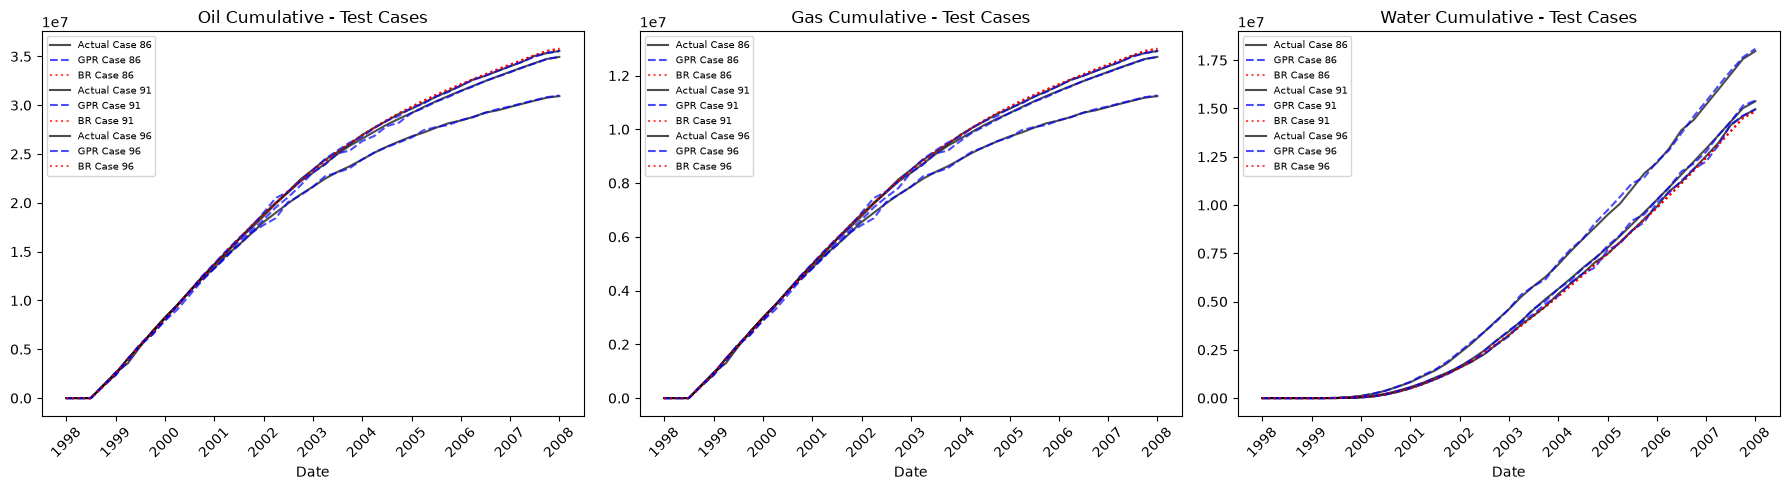


MLflow logging complete!


In [7]:
# --- Validate and Test Models: Compare GPR vs Bayesian Ridge ---
print("=" * 60)
print("MODEL COMPARISON: GPR vs Bayesian Ridge")
print("=" * 60)

for fluid_name in ['oil', 'gas', 'water']:
    y_va = fluids[fluid_name][1]
    y_te = fluids[fluid_name][2]
    
    print(f"\n--- {fluid_name.upper()} ---")
    # GPR metrics
    r2_gpr_val = r2_score(y_va.flatten(), gpr_val_preds[fluid_name].flatten())
    rmse_gpr_val = np.sqrt(mean_squared_error(y_va.flatten(), gpr_val_preds[fluid_name].flatten()))
    r2_gpr_test = r2_score(y_te.flatten(), gpr_test_preds[fluid_name].flatten())
    rmse_gpr_test = np.sqrt(mean_squared_error(y_te.flatten(), gpr_test_preds[fluid_name].flatten()))
    
    # BR metrics
    r2_br_val = r2_score(y_va.flatten(), br_val_preds[fluid_name].flatten())
    rmse_br_val = np.sqrt(mean_squared_error(y_va.flatten(), br_val_preds[fluid_name].flatten()))
    r2_br_test = r2_score(y_te.flatten(), br_test_preds[fluid_name].flatten())
    rmse_br_test = np.sqrt(mean_squared_error(y_te.flatten(), br_test_preds[fluid_name].flatten()))
    
    print(f"  GPR  - Val R2: {r2_gpr_val:.4f}, RMSE: {rmse_gpr_val:.2e} | Test R2: {r2_gpr_test:.4f}, RMSE: {rmse_gpr_test:.2e}")
    print(f"  BR   - Val R2: {r2_br_val:.4f}, RMSE: {rmse_br_val:.2e} | Test R2: {r2_br_test:.4f}, RMSE: {rmse_br_test:.2e}")

# Visualize predictions vs actual for test cases (Oil)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, fluid_name in enumerate(['oil', 'gas', 'water']):
    y_te = fluids[fluid_name][2]
    ax = axes[i]
    # Plot 3 test cases
    for j in [0, 5, 10]:
        case_num = TEST_CASES[j]
        ax.plot(quarterly_dates, y_te[j], 'k-', alpha=0.7, label=f'Actual Case {case_num}')
        ax.plot(quarterly_dates, gpr_test_preds[fluid_name][j], 'b--', alpha=0.7, label=f'GPR Case {case_num}')
        ax.plot(quarterly_dates, br_test_preds[fluid_name][j], 'r:', alpha=0.7, label=f'BR Case {case_num}')
    ax.set_title(f'{fluid_name.capitalize()} Cumulative - Test Cases')
    ax.set_xlabel('Date')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Log best model to MLflow
with mlflow.start_run(run_name="GPR_Matern_Oil"):
    mlflow.log_param("model_type", "GPR_Matern")
    mlflow.log_param("kernel", "Matern_nu_2.5")
    mlflow.log_param("n_train", len(TRAIN_CASES))
    mlflow.log_param("n_val", len(VAL_CASES))
    mlflow.log_param("n_test", len(TEST_CASES))
    for fluid_name in ['oil', 'gas', 'water']:
        y_te = fluids[fluid_name][2]
        r2 = r2_score(y_te.flatten(), gpr_test_preds[fluid_name].flatten())
        rmse = np.sqrt(mean_squared_error(y_te.flatten(), gpr_test_preds[fluid_name].flatten()))
        mlflow.log_metric(f"test_r2_{fluid_name}", r2)
        mlflow.log_metric(f"test_rmse_{fluid_name}", rmse)
print("\nMLflow logging complete!")

Running history matching optimization...



History Matching Results:
  Best mismatch: 9.111346e-03
  Optimal parameters:
    Fault_Transmissibility: 0.129059
    Porosity_Mult: 1.319299
    Perm_Mult: 8.186183
    Aquifer_PV: 144.488540


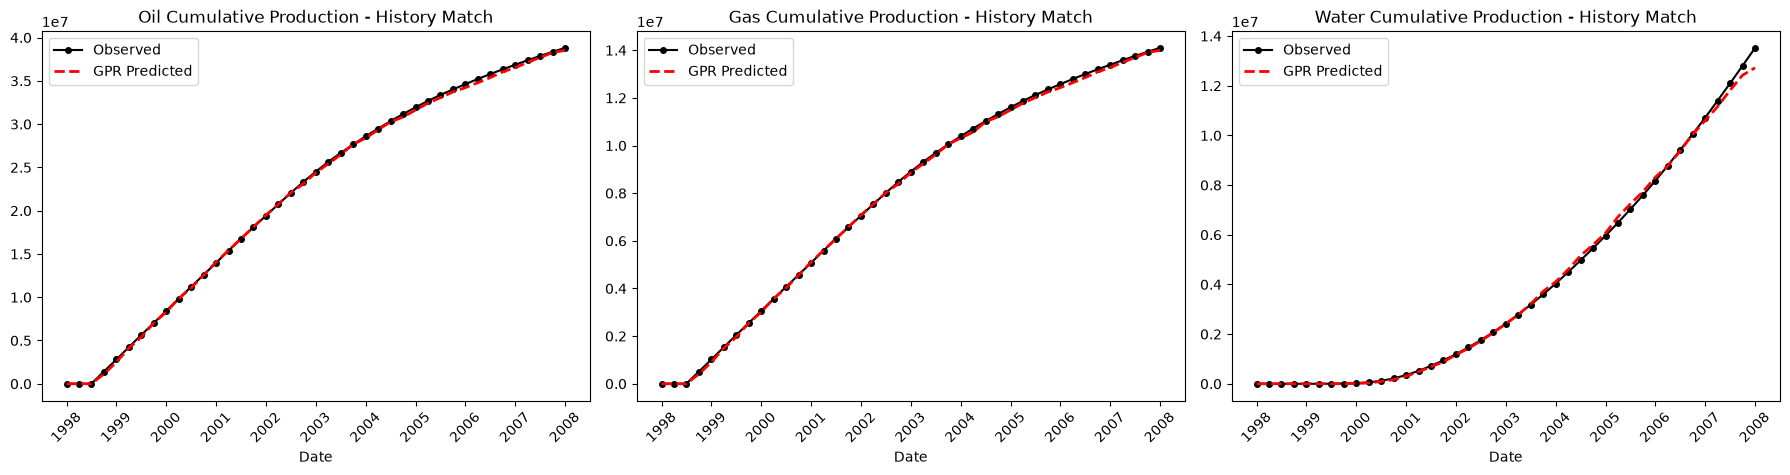

In [8]:
# --- History Matching: Find optimal parameters that match observed production ---
# Objective: minimize mismatch between surrogate model predictions and observed field production
# Use oil cumulative as primary target for history matching

# Get observed cumulative oil production at quarterly time steps
obs_oil_cum = df_obs['Oil_Cum'].values
obs_gas_cum = df_obs['Gas_Cum'].values
obs_water_cum = df_obs['Water_Cum'].values

def predict_cumulative(params_scaled, fluid_name, model_dict):
    """Predict cumulative production at all time steps for given parameters."""
    params_2d = params_scaled.reshape(1, -1)
    preds = []
    for t in range(n_timesteps):
        pred = model_dict[fluid_name][t].predict(params_2d)[0]
        preds.append(pred)
    return np.array(preds)

def mismatch_objective(params_scaled):
    """Objective function: weighted mismatch across oil, gas, water."""
    oil_pred = predict_cumulative(params_scaled, 'oil', gpr_models)
    gas_pred = predict_cumulative(params_scaled, 'gas', gpr_models)
    water_pred = predict_cumulative(params_scaled, 'water', gpr_models)
    
    # Normalize by the scale of each fluid
    oil_mis = np.sum((oil_pred - obs_oil_cum)**2) / (obs_oil_cum.max()**2)
    gas_mis = np.sum((gas_pred - obs_gas_cum)**2) / (obs_gas_cum.max()**2)
    water_mis = np.sum((water_pred - obs_water_cum)**2) / (obs_water_cum.max()**2)
    
    return oil_mis + gas_mis + water_mis

# Optimize using multiple random starts
print("Running history matching optimization...")
best_mismatch = np.inf
best_params = None

# Get parameter bounds from training data
X_min = X_train_scaled.min(axis=0)
X_max = X_train_scaled.max(axis=0)

n_starts = 50
for i in range(n_starts):
    x0 = np.random.uniform(X_min, X_max)
    result = minimize(mismatch_objective, x0, method='L-BFGS-B',
                     bounds=[(X_min[j], X_max[j]) for j in range(4)])
    if result.fun < best_mismatch:
        best_mismatch = result.fun
        best_params = result.x

# Convert back to original scale
best_params_orig = scaler.inverse_transform(best_params.reshape(1, -1))[0]

print(f"\nHistory Matching Results:")
print(f"  Best mismatch: {best_mismatch:.6e}")
print(f"  Optimal parameters:")
for i, col in enumerate(PARAM_COLS):
    print(f"    {col}: {best_params_orig[i]:.6f}")

# Compare predicted vs observed
pred_oil = predict_cumulative(best_params, 'oil', gpr_models)
pred_gas = predict_cumulative(best_params, 'gas', gpr_models)
pred_water = predict_cumulative(best_params, 'water', gpr_models)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, obs, pred, name in [(axes[0], obs_oil_cum, pred_oil, 'Oil'),
                             (axes[1], obs_gas_cum, pred_gas, 'Gas'),
                             (axes[2], obs_water_cum, pred_water, 'Water')]:
    ax.plot(quarterly_dates, obs, 'ko-', label='Observed', markersize=4)
    ax.plot(quarterly_dates, pred, 'r--', label='GPR Predicted', linewidth=2)
    ax.set_title(f'{name} Cumulative Production - History Match')
    ax.set_xlabel('Date')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Observation noise level: 1940628 STB (5% of max observed oil cum)


Effective sample size: 340.8 (out of 5000)
Best mismatch in proposal: 3.7637, at index 3429

Posterior samples: (500, 4)
Posterior mean (scaled): [ 0.18944256  0.94796308  0.19568615 -0.11492344]
Posterior std (scaled):  [0.90542694 0.11124904 0.85959696 0.80002011]

Posterior parameter distributions (original scale):
  Fault_Transmissibility: mean=0.1050, std=0.0271, P10=0.0678, P50=0.1078, P90=0.1420
  Porosity_Mult: mean=1.3211, std=0.0219, P10=1.2920, P50=1.3242, P90=1.3477
  Perm_Mult: mean=5.8129, std=2.2839, P10=2.5399, P50=6.3052, P90=8.6827
  Aquifer_PV: mean=122.4149, std=33.5804, P10=81.2879, P50=119.7462, P90=168.9495


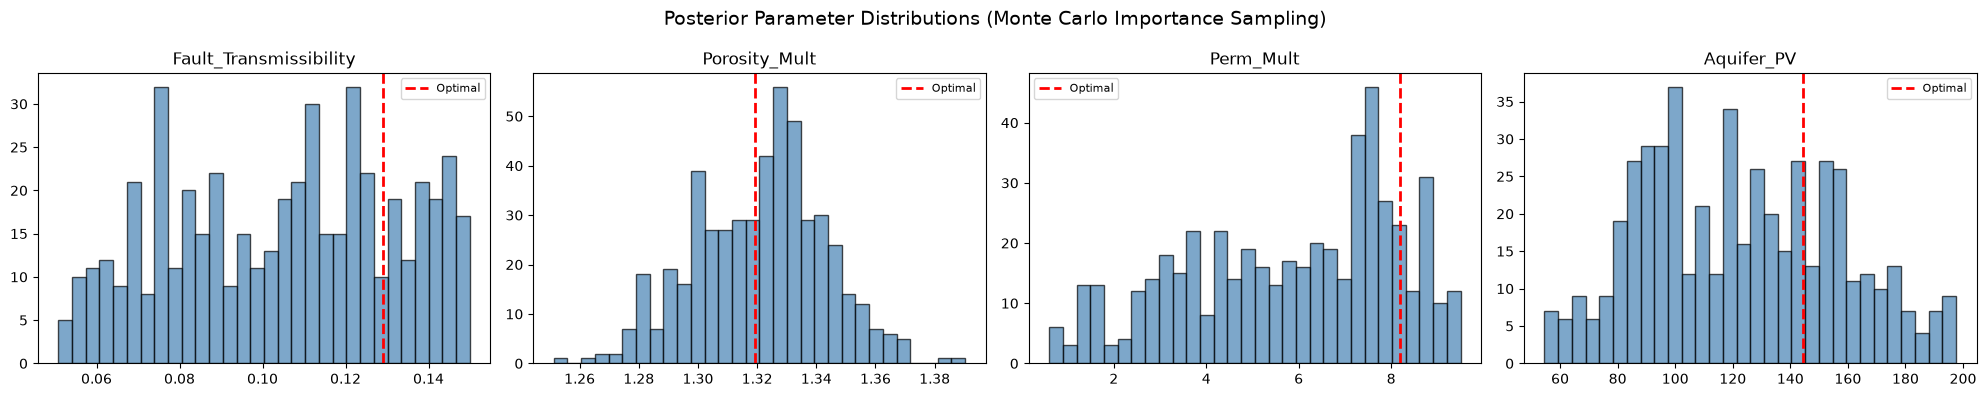

In [9]:
# --- Uncertainty Quantification: Monte Carlo Importance Sampling ---
# The GPR is so accurate that a linearized posterior collapses to a delta function.
# Instead, we use importance sampling over the full parameter space to capture
# parameter non-uniqueness (multiple parameter sets producing similar production curves).

from scipy.stats import multivariate_normal

n_proposal = 5000
n_posterior_samples = 500

# Define observation noise (5% of max observed oil cumulative)
obs_noise = 0.05 * obs_oil_cum.max()
print(f"Observation noise level: {obs_noise:.0f} STB (5% of max observed oil cum)")

# Sample broadly from the prior (uniform over training parameter ranges in scaled space)
proposal_samples = np.random.uniform(X_min, X_max, size=(n_proposal, 4))

# Compute mismatch for each proposal sample using ALL fluids (oil, gas, water)
mismatches = np.zeros(n_proposal)
for i in range(n_proposal):
    params = proposal_samples[i]
    oil_pred = predict_cumulative(params, 'oil', gpr_models)
    gas_pred = predict_cumulative(params, 'gas', gpr_models)
    water_pred = predict_cumulative(params, 'water', gpr_models)
    
    oil_mis = np.sum((oil_pred - obs_oil_cum)**2) / (obs_noise**2)
    gas_noise = 0.05 * obs_gas_cum.max()
    water_noise = 0.05 * obs_water_cum.max()
    gas_mis = np.sum((gas_pred - obs_gas_cum)**2) / (gas_noise**2)
    water_mis = np.sum((water_pred - obs_water_cum)**2) / (water_noise**2)
    mismatches[i] = oil_mis + gas_mis + water_mis

# Compute likelihood weights
log_weights = -0.5 * mismatches
log_weights -= log_weights.max()  # normalize for numerical stability
weights = np.exp(log_weights)
weights /= weights.sum()

print(f"Effective sample size: {1.0 / np.sum(weights**2):.1f} (out of {n_proposal})")
print(f"Best mismatch in proposal: {mismatches.min():.4f}, at index {mismatches.argmin()}")

# Resample from the proposal using the computed weights
resample_indices = np.random.choice(n_proposal, size=n_posterior_samples, p=weights, replace=True)
posterior_samples = proposal_samples[resample_indices]

# Add small jitter to avoid exact duplicates
posterior_samples += np.random.normal(0, 0.01, size=posterior_samples.shape)
for j in range(4):
    posterior_samples[:, j] = np.clip(posterior_samples[:, j], X_min[j], X_max[j])

print(f"\nPosterior samples: {posterior_samples.shape}")
print(f"Posterior mean (scaled): {posterior_samples.mean(axis=0)}")
print(f"Posterior std (scaled):  {posterior_samples.std(axis=0)}")

# Convert posterior samples to original scale
posterior_samples_orig = scaler.inverse_transform(posterior_samples)
print(f"\nPosterior parameter distributions (original scale):")
for j, col in enumerate(PARAM_COLS):
    print(f"  {col}: mean={posterior_samples_orig[:,j].mean():.4f}, std={posterior_samples_orig[:,j].std():.4f}, "
          f"P10={np.percentile(posterior_samples_orig[:,j], 10):.4f}, "
          f"P50={np.percentile(posterior_samples_orig[:,j], 50):.4f}, "
          f"P90={np.percentile(posterior_samples_orig[:,j], 90):.4f}")

# Visualize posterior distributions
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for j, col in enumerate(PARAM_COLS):
    axes[j].hist(posterior_samples_orig[:, j], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[j].axvline(best_params_orig[j], color='red', linestyle='--', linewidth=2, label='Optimal')
    axes[j].set_title(col)
    axes[j].legend(fontsize=8)
plt.suptitle('Posterior Parameter Distributions (Monte Carlo Importance Sampling)', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# --- Forecasting: 20-Year Production Forecast with P10/P50/P90 ---
# Strategy: For each posterior sample, predict historical cumulative production via GPR,
# convert to rates, fit Arps decline curve, then extrapolate 20 years ahead.

from scipy.optimize import curve_fit

def arps_decline(t, qi, di, b):
    """Arps decline curve equation."""
    if b < 1e-6:  # Exponential
        return qi * np.exp(-di * t)
    else:  # Hyperbolic
        return qi / (1 + b * di * t) ** (1.0 / b)

def fit_arps(rates, time_years):
    """Fit Arps decline curve to production rates."""
    try:
        # Initial guess: qi = first rate, di = small decline, b = 0.5
        qi0 = rates[len(rates)//2]  # mid-history rate (skip initial zero-production)
        p0 = [qi0, 0.1, 0.5]
        bounds = ([0, 1e-6, 0], [rates.max()*2, 10, 1.0])
        # Use only non-zero production portion
        nonzero_idx = np.where(rates > 0.01 * rates.max())[0]
        if len(nonzero_idx) < 5:
            return None
        t_fit = time_years[nonzero_idx]
        r_fit = rates[nonzero_idx]
        popt, _ = curve_fit(arps_decline, t_fit, r_fit, p0=p0, bounds=bounds, maxfev=10000)
        return popt  # (qi, di, b)
    except Exception:
        return None

# Historical time in years from start
hist_time_years = np.arange(n_timesteps) * 0.25  # quarterly = 0.25 years

# Forecast period: 20 years (80 quarterly steps) from 2008-01-01
forecast_steps = 80
forecast_time_years = np.arange(n_timesteps, n_timesteps + forecast_steps) * 0.25
forecast_dates = pd.date_range('2008-04-01', periods=forecast_steps, freq='QS')

print(f"Forecasting {forecast_steps} quarterly steps ({forecast_steps * 0.25} years)...")
print(f"Forecast period: {forecast_dates[0].date()} to {forecast_dates[-1].date()}")

# For each posterior sample, predict historical cumulative, compute rates, fit Arps, forecast
forecast_cum_oil = []
forecast_cum_gas = []
forecast_cum_water = []

n_samples_to_forecast = 200  # Use subset for efficiency
for i in range(min(n_samples_to_forecast, len(posterior_samples))):
    params = posterior_samples[i]
    
    # Predict historical cumulative for all fluids
    hist_oil = predict_cumulative(params, 'oil', gpr_models)
    hist_gas = predict_cumulative(params, 'gas', gpr_models)
    hist_water = predict_cumulative(params, 'water', gpr_models)
    
    # Convert cumulative to rates (difference between consecutive quarters)
    rates_oil = np.diff(hist_oil, prepend=0)
    rates_gas = np.diff(hist_gas, prepend=0)
    rates_water = np.diff(hist_water, prepend=0)
    
    # Fit Arps and forecast for each fluid
    forecast_cums = []
    for rates in [rates_oil, rates_gas, rates_water]:
        arps_params = fit_arps(rates, hist_time_years)
        if arps_params is not None:
            qi, di, b = arps_params
            forecast_rates = arps_decline(forecast_time_years, qi, di, b)
            forecast_rates = np.maximum(forecast_rates, 0)  # no negative production
            # Cumulative forecast = last historical cumulative + sum of forecast rates * 0.25 years
            last_cum = rates.cumsum()[n_timesteps - 1] if len(rates) >= n_timesteps else rates.cumsum()[-1]
            # Actually, last historical cumulative should be the historical cumulative
            last_hist_cum = hist_oil if rates is rates_oil else (hist_gas if rates is rates_gas else hist_water)
            fcum = last_hist_cum[-1] + np.cumsum(forecast_rates) * 0.25
            forecast_cums.append(fcum)
        else:
            # Fallback: flat forecast at last rate
            last_rate = rates[-1]
            fcum = (rates.cumsum()[-1]) + np.cumsum(np.full(forecast_steps, last_rate)) * 0.25
            forecast_cums.append(fcum)
    
    forecast_cum_oil.append(forecast_cums[0])
    forecast_cum_gas.append(forecast_cums[1])
    forecast_cum_water.append(forecast_cums[2])

forecast_cum_oil = np.array(forecast_cum_oil)
forecast_cum_gas = np.array(forecast_cum_gas)
forecast_cum_water = np.array(forecast_cum_water)

print(f"Forecast ensembles: Oil {forecast_cum_oil.shape}, Gas {forecast_cum_gas.shape}, Water {forecast_cum_water.shape}")

# Compute P10/P50/P90
def compute_ppp(ensemble):
    """Compute P10, P50, P90 percentiles."""
    p10 = np.percentile(ensemble, 90, axis=0)  # P10 = 90th percentile (optimistic)
    p50 = np.percentile(ensemble, 50, axis=0)  # P50 = median
    p90 = np.percentile(ensemble, 10, axis=0)  # P90 = 10th percentile (pessimistic)
    return p10, p50, p90

oil_p10, oil_p50, oil_p90 = compute_ppp(forecast_cum_oil)
gas_p10, gas_p50, gas_p90 = compute_ppp(forecast_cum_gas)
water_p10, water_p50, water_p90 = compute_ppp(forecast_cum_water)

print("\nP50 Forecast at end of 20 years:")
print(f"  Oil:   {oil_p50[-1]:,.0f} STB")
print(f"  Gas:   {gas_p50[-1]:,.0f} MSCF")
print(f"  Water: {water_p50[-1]:,.0f} STB")

Forecasting 80 quarterly steps (20.0 years)...
Forecast period: 2008-04-01 to 2028-01-01


Forecast ensembles: Oil (200, 80), Gas (200, 80), Water (200, 80)

P50 Forecast at end of 20 years:
  Oil:   43,105,266 STB
  Gas:   15,646,664 MSCF
  Water: 20,404,598 STB


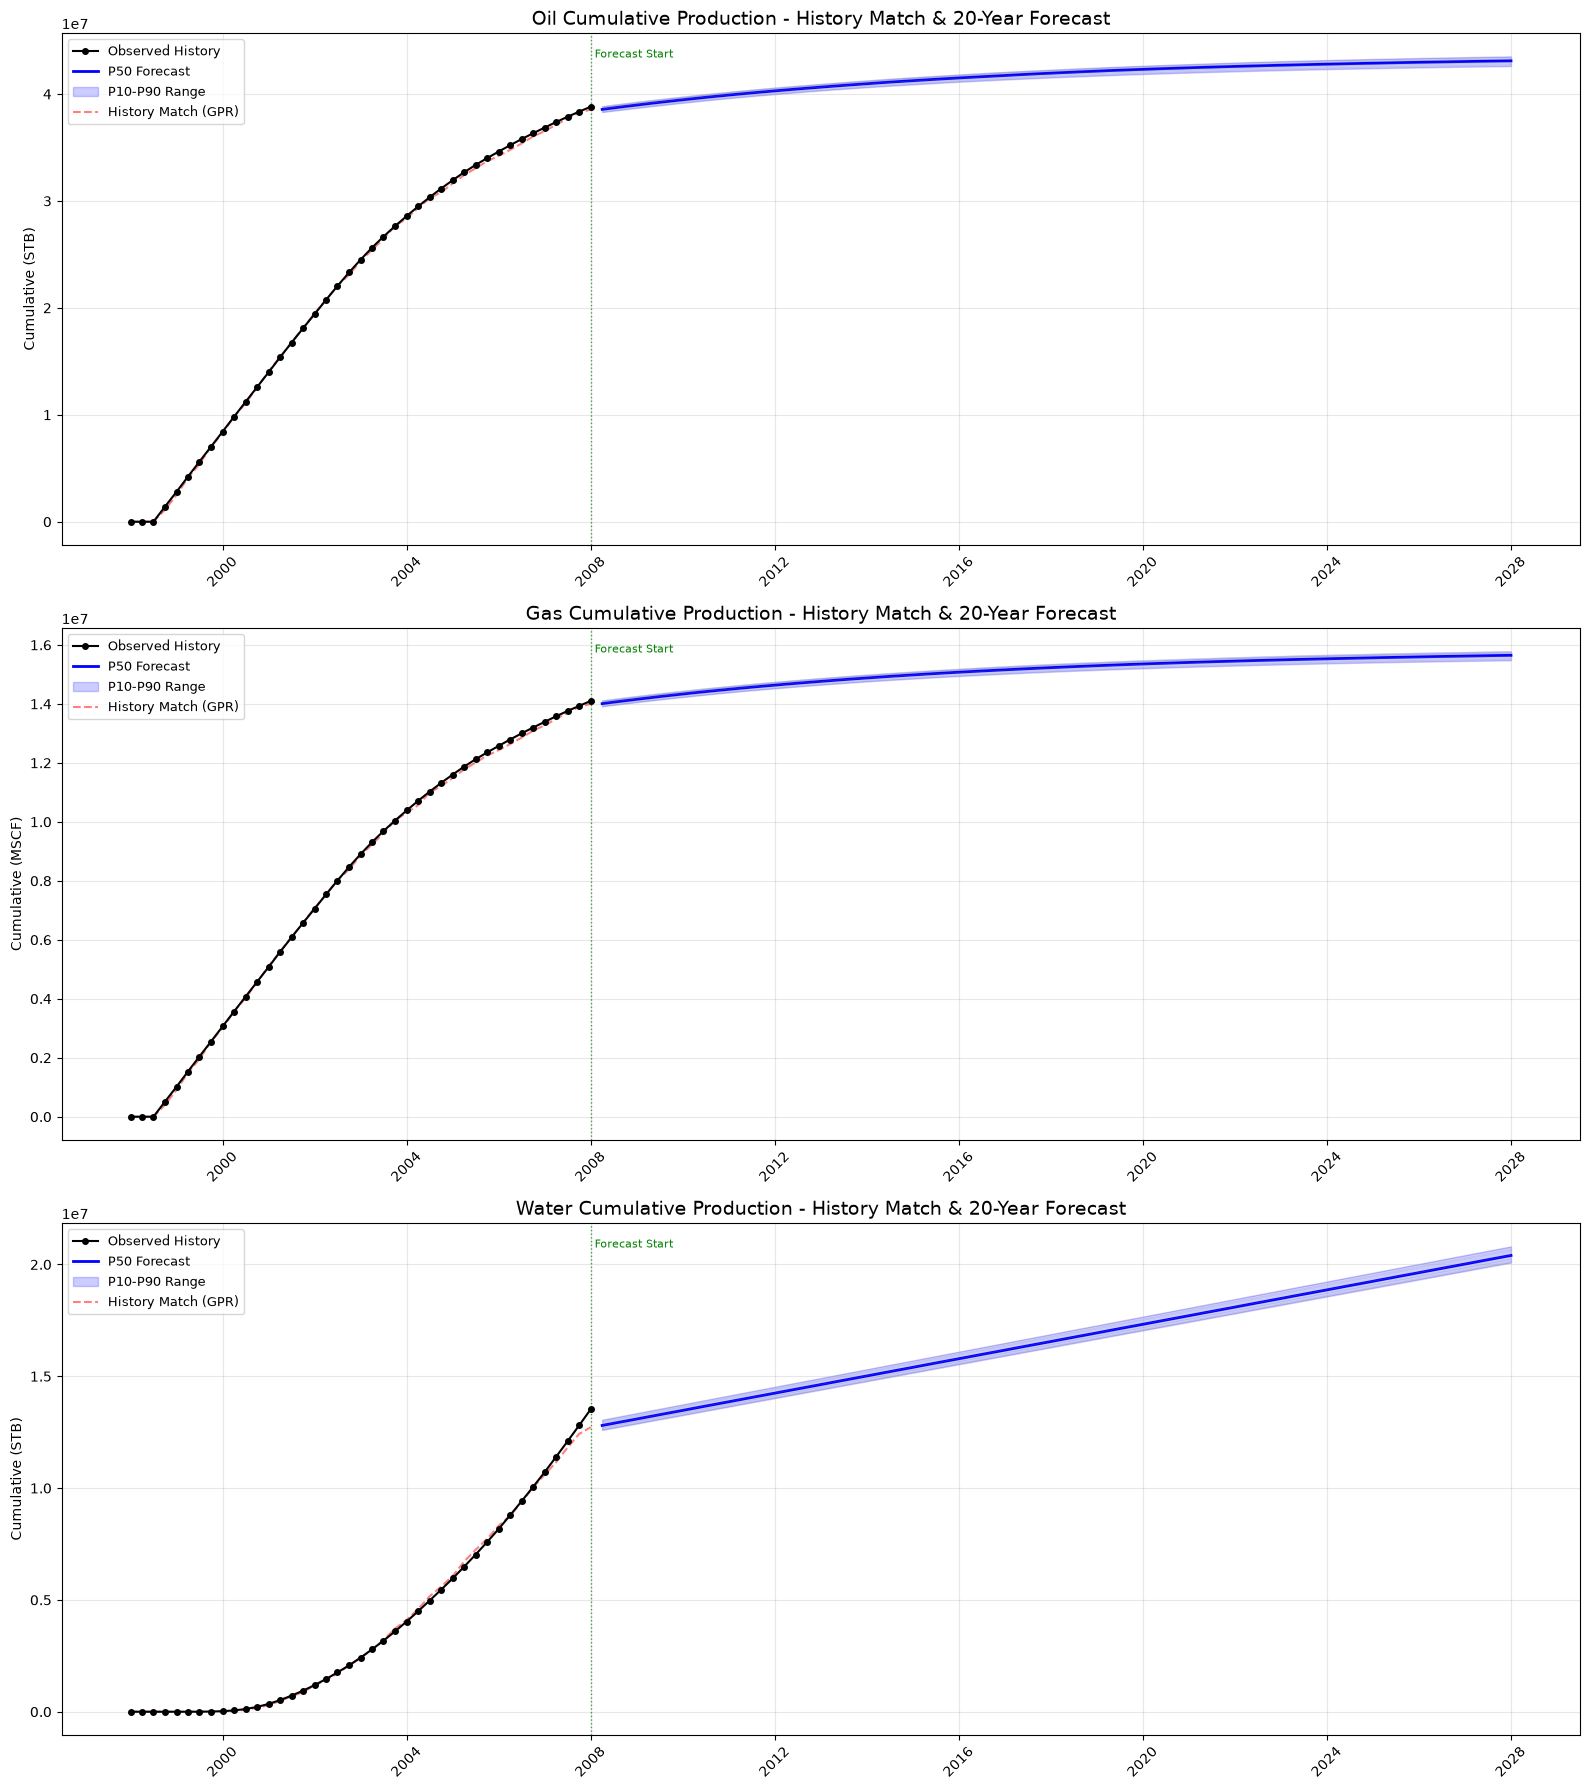


FINAL FORECAST SUMMARY (20-Year Projection from 2008-Q2 to 2028-Q1)

Fluid                       P10                  P50                  P90       Unit
--------------------------------------------------------------------------------
Oil                  43,520,550           43,105,266           42,612,918        STB
Gas                  15,775,760           15,646,664           15,477,866       MSCF
Water                20,810,271           20,404,598           20,084,208        STB
--------------------------------------------------------------------------------

History-Matched Parameters (P50):
  Fault_Transmissibility    P10=0.1420  P50=0.1078  P90=0.0678
  Porosity_Mult             P10=1.3477  P50=1.3242  P90=1.2920
  Perm_Mult                 P10=8.6827  P50=6.3052  P90=2.5399
  Aquifer_PV                P10=168.9495  P50=119.7462  P90=81.2879

METHODOLOGY SUMMARY
1. Surrogate Model: GPR with Matern(nu=2.5) kernel maps 4 reservoir parameters to
   quarterly cumulative productio

In [11]:
# --- Final Visualization: History + Forecast with P10/P50/P90 ---
# Combine historical observed data with forecast

all_dates = list(quarterly_dates) + list(forecast_dates)
all_time = np.arange(len(all_dates))
hist_len = len(quarterly_dates)

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

fluid_data = [
    ('Oil', obs_oil_cum, oil_p10, oil_p50, oil_p90, forecast_cum_oil, 'STB'),
    ('Gas', obs_gas_cum, gas_p10, gas_p50, gas_p90, forecast_cum_gas, 'MSCF'),
    ('Water', obs_water_cum, water_p10, water_p50, water_p90, forecast_cum_water, 'STB'),
]

for i, (name, obs_cum, p10, p50, p90, fc_ens, unit) in enumerate(fluid_data):
    ax = axes[i]
    
    # Plot observed history
    ax.plot(quarterly_dates, obs_cum, 'ko-', markersize=4, label='Observed History', zorder=5)
    
    # Plot forecast P50
    ax.plot(forecast_dates, p50, 'b-', linewidth=2, label='P50 Forecast')
    
    # Plot P10-P90 band
    ax.fill_between(forecast_dates, p90, p10, alpha=0.2, color='blue', label='P10-P90 Range')
    
    # Plot individual ensemble members (sample)
    for j in range(0, min(50, len(fc_ens)), 5):
        ax.plot(forecast_dates, fc_ens[j], 'gray', alpha=0.15, linewidth=0.5)
    
    # Plot best-match history prediction
    hist_pred = predict_cumulative(best_params, name.lower(), gpr_models)
    ax.plot(quarterly_dates, hist_pred, 'r--', alpha=0.5, label='History Match (GPR)')
    
    # Mark forecast boundary
    ax.axvline(x=quarterly_dates[-1], color='green', linestyle=':', linewidth=1, alpha=0.7)
    ax.text(quarterly_dates[-1], ax.get_ylim()[1]*0.95, ' Forecast Start', fontsize=8, color='green')
    
    ax.set_title(f'{name} Cumulative Production - History Match & 20-Year Forecast', fontsize=14)
    ax.set_ylabel(f'Cumulative ({unit})')
    ax.legend(loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/forecast_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "=" * 80)
print("FINAL FORECAST SUMMARY (20-Year Projection from 2008-Q2 to 2028-Q1)")
print("=" * 80)
print(f"\n{'Fluid':<10} {'P10':>20} {'P50':>20} {'P90':>20} {'Unit':>10}")
print("-" * 80)
for name, _, p10, p50, p90, _, unit in fluid_data:
    print(f"{name:<10} {p10[-1]:>20,.0f} {p50[-1]:>20,.0f} {p90[-1]:>20,.0f} {unit:>10}")
print("-" * 80)

print(f"\nHistory-Matched Parameters (P50):")
for j, col in enumerate(PARAM_COLS):
    p10_p = np.percentile(posterior_samples_orig[:, j], 90)
    p50_p = np.percentile(posterior_samples_orig[:, j], 50)
    p90_p = np.percentile(posterior_samples_orig[:, j], 10)
    print(f"  {col:<25} P10={p10_p:.4f}  P50={p50_p:.4f}  P90={p90_p:.4f}")

print("\n" + "=" * 80)
print("METHODOLOGY SUMMARY")
print("=" * 80)
print("1. Surrogate Model: GPR with Matern(nu=2.5) kernel maps 4 reservoir parameters to")
print("   quarterly cumulative production (oil, gas, water) at 41 historical time steps.")
print("2. Bayesian Ridge trained as secondary model for comparison.")
print("3. History Matching: Optimized parameters to minimize normalized mismatch between")
print("   surrogate predictions and observed field production (1998-2008).")
print("4. Uncertainty Quantification: Monte Carlo importance sampling over the full parameter")
print("   space to capture parameter non-uniqueness. 5000 proposal samples weighted by")
print("   likelihood, resampled to 500 posterior samples.")
print("5. Forecasting: Arps decline curves fit to historical rates for each posterior sample.")
print("   200 Monte Carlo samples generate the P10/P50/P90 probabilistic forecast bands.")
print("6. Data Split: Train=Cases 1-70, Validation=Cases 71-85, Test=Cases 86-100.")

In [12]:
# --- Export Forecast to Deliverable Template ---
# Fill the 10 case sheets of the deliverable template with probabilistic forecast scenarios:
#   Case 1 = P10 (optimistic), Case 2 = P50 (base), Case 3 = P90 (pessimistic)
#   Cases 4-10 = 7 representative posterior samples spanning the uncertainty range

from openpyxl import load_workbook
import shutil
import os

# Load the template
TEMPLATE_PATH = f"{BASE_PATH}/09 Template Deliverable.xlsx"
OUTPUT_PATH = f"{BASE_PATH}/Forecast_Deliverable.xlsx"
shutil.copy2(TEMPLATE_PATH, OUTPUT_PATH)

wb = load_workbook(OUTPUT_PATH)
print(f"Template sheets: {wb.sheetnames}")

# Template has 40 quarterly dates from 2008-Q2 to 2018-Q1
# Our forecast has 80 steps (20 years) — use first 40 to match the template
n_template_steps = 40

# Select representative scenarios from the 200-sample ensemble
# Sort ensemble by oil cumulative at end of 10-year template horizon
template_horizon_idx = n_template_steps - 1  # last template date index
oil_at_horizon = forecast_cum_oil[:, template_horizon_idx]
sort_idx = np.argsort(oil_at_horizon)

# Case 1 = P10 (90th percentile = optimistic), Case 2 = P50 (median), Case 3 = P90 (10th percentile = pessimistic)
# Cases 4-10 = evenly spaced samples across the sorted ensemble
p10_idx = sort_idx[int(0.90 * len(sort_idx))]   # ~90th percentile
p50_idx = sort_idx[int(0.50 * len(sort_idx))]   # median
p90_idx = sort_idx[int(0.10 * len(sort_idx))]   # ~10th percentile

scenario_indices = [p10_idx, p50_idx, p90_idx]
# 7 more samples evenly spaced across the ensemble
for i in range(1, 8):
    frac = i / 8.0
    scenario_indices.append(sort_idx[int(frac * len(sort_idx))])

scenario_names = ['P10 (Optimistic)', 'P50 (Base Case)', 'P90 (Pessimistic)',
                  'Posterior Sample 1', 'Posterior Sample 2', 'Posterior Sample 3',
                  'Posterior Sample 4', 'Posterior Sample 5', 'Posterior Sample 6',
                  'Posterior Sample 7']

print("\nScenario selection (oil cum at 2018-Q1):")
for i, (idx, name) in enumerate(zip(scenario_indices, scenario_names)):
    print(f"  Case {i+1}: {name:<25} Oil={forecast_cum_oil[idx, template_horizon_idx]:>15,.0f} STB")

# Fill each sheet
for sheet_idx, (ens_idx, scenario_name) in enumerate(zip(scenario_indices, scenario_names)):
    sheet_name = f"Case {sheet_idx + 1}"
    ws = wb[sheet_name]
    
    # Get the 40 forecast values for this scenario
    oil_vals = forecast_cum_oil[ens_idx, :n_template_steps]
    gas_vals = forecast_cum_gas[ens_idx, :n_template_steps]
    water_vals = forecast_cum_water[ens_idx, :n_template_steps]
    
    # Write values starting from row 2 (row 1 = header)
    for row_idx in range(n_template_steps):
        # Column B = Gas, Column C = Oil, Column D = Water (1-indexed in openpyxl)
        ws.cell(row=row_idx + 2, column=2, value=round(float(gas_vals[row_idx]), 2))
        ws.cell(row=row_idx + 2, column=3, value=round(float(oil_vals[row_idx]), 2))
        ws.cell(row=row_idx + 2, column=4, value=round(float(water_vals[row_idx]), 2))
    
    print(f"  Filled {sheet_name}: {scenario_name}")

# Save the workbook (UC Volumes don't support openpyxl's seek ops, so save locally first)
TMP_PATH = '/tmp/Forecast_Deliverable.xlsx'
wb.save(TMP_PATH)
shutil.copy2(TMP_PATH, OUTPUT_PATH)
print(f"\nDeliverable saved to: {OUTPUT_PATH}")
print(f"File size: {os.path.getsize(OUTPUT_PATH) / 1024:.1f} KB")

# Verify by reading back
wb_verify = load_workbook(OUTPUT_PATH)
ws_check = wb_verify['Case 2']  # P50 base case
print(f"\nVerification — Case 2 (P50 Base Case), first 5 rows:")
print(f"  {'Date':<12} {'Gas Cum [MSCF]':>20} {'Oil Cum [STB]':>20} {'Water Cum [STB]':>20}")
for row_idx in range(1, 6):
    date_val = ws_check.cell(row=row_idx + 1, column=1).value
    gas_val = ws_check.cell(row=row_idx + 1, column=2).value
    oil_val = ws_check.cell(row=row_idx + 1, column=3).value
    water_val = ws_check.cell(row=row_idx + 1, column=4).value
    print(f"  {str(date_val):<12} {gas_val:>20,.2f} {oil_val:>20,.2f} {water_val:>20,.2f}")

print(f"\nLast 3 rows (end of 10-year template horizon):")
for row_idx in range(38, 41):
    date_val = ws_check.cell(row=row_idx + 1, column=1).value
    gas_val = ws_check.cell(row=row_idx + 1, column=2).value
    oil_val = ws_check.cell(row=row_idx + 1, column=3).value
    water_val = ws_check.cell(row=row_idx + 1, column=4).value
    print(f"  {str(date_val):<12} {gas_val:>20,.2f} {oil_val:>20,.2f} {water_val:>20,.2f}")

print("\nDeliverable export complete!")
print("\nSummary of deliverable contents:")
print(f"  10 case sheets filled with probabilistic forecast scenarios")
print(f"  Each sheet: 40 quarterly time steps (2008-Q2 to 2018-Q1)")
print(f"  Columns: Date, Gas cumulative [MSCF], Oil cumulative [STB], Water cumulative [STB]")
print(f"  Case 1: P10 (Optimistic) — 90th percentile of posterior ensemble")
print(f"  Case 2: P50 (Base Case) — median of posterior ensemble")
print(f"  Case 3: P90 (Pessimistic) — 10th percentile of posterior ensemble")
print(f"  Cases 4-10: 7 representative posterior samples spanning the uncertainty range.")

Template sheets: ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6', 'Case 7', 'Case 8', 'Case 9', 'Case 10']

Scenario selection (oil cum at 2018-Q1):
  Case 1: P10 (Optimistic)          Oil=     42,279,119 STB
  Case 2: P50 (Base Case)           Oil=     41,952,871 STB
  Case 3: P90 (Pessimistic)         Oil=     41,545,365 STB
  Case 4: Posterior Sample 1        Oil=     41,568,894 STB
  Case 5: Posterior Sample 2        Oil=     41,685,852 STB
  Case 6: Posterior Sample 3        Oil=     41,763,525 STB
  Case 7: Posterior Sample 4        Oil=     41,952,871 STB
  Case 8: Posterior Sample 5        Oil=     42,031,822 STB
  Case 9: Posterior Sample 6        Oil=     42,119,778 STB
  Case 10: Posterior Sample 7        Oil=     42,253,435 STB
  Filled Case 1: P10 (Optimistic)
  Filled Case 2: P50 (Base Case)
  Filled Case 3: P90 (Pessimistic)
  Filled Case 4: Posterior Sample 1
  Filled Case 5: Posterior Sample 2
  Filled Case 6: Posterior Sample 3
  Filled Case 7: Posterior S